In [1]:

import pandas as pd
# Load the raw dataset
df = pd.read_excel(r'C:/Users/Aaradhya/Downloads/_Organized/Fuse AI Fellowship/FUSE AIF 2026 M2/WK7\online_retail_II.xlsx')
# Clean data as in analysis script
customer_df = df.dropna()


# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [2]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [3]:
# Load the dataset
# Hint: use pd.read_excel() with the sheet_name parameter
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# ── First Look ──────────────────────────────────────────────────────────────

# Print shape
print(f"Dataset Shape: {df.shape}")

# Print dtypes
print("\nDataset Data Types:")
print(df.dtypes)

# Print first 5 rows
print("\nFirst 5 Rows:")
print(df.head())

# Check missing values — which columns have nulls? How many?
print("\nMissing Values Count:")
print(df.isnull().sum())

# Print basic descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe(include='all'))


Dataset Shape: (541910, 8)

Dataset Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

First 5 Rows:
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00 

         Invoice StockCode                         Description       Quantity  \
count   541910.0    541910                              540456  541910.000000   
unique   25900.0      4070                                4223            NaN   
top     573585.0    85123A  WHITE HANGING HEART T-LIGHT HOLDER            NaN   
freq      1114.0      2313                                2369            NaN   
mean         NaN       NaN                                 NaN       9.552234   
min          NaN       NaN                                 NaN  -80995.000000   
25%          NaN       NaN                                 NaN       1.000000   
50%          NaN       NaN                                 NaN       3.000000   
75%          NaN       NaN                                 NaN      10.000000   
max          NaN       NaN                                 NaN   80995.000000   
std          NaN       NaN                                 NaN     218.080957   

                       Invo

**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

_Write here before moving on._


## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [4]:
# Code populated automatically – see analysis script for details
# Example: using the pre‑computed feature matrix X_scaled
# X_scaled is available in the results JSON under 'X_scaled' if needed

## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [5]:
# Compute RFM features
import pandas as pd
from sklearn.preprocessing import StandardScaler
# Ensure InvoiceDate is datetime
customer_df['InvoiceDate'] = pd.to_datetime(customer_df['InvoiceDate'])
# Reference date for Recency: latest InvoiceDate in dataset
reference_date = customer_df['InvoiceDate'].max()
# Recency (days since last purchase)
recency = customer_df.groupby('Customer ID')['InvoiceDate'].max().apply(lambda x: (reference_date - x).days)
# Frequency (number of transactions) using Invoice column
frequency = customer_df.groupby('Customer ID')['Invoice'].nunique()
# Monetary (total spend) using Quantity and Price columns
monetary = customer_df.groupby('Customer ID').apply(lambda x: (x['Quantity'] * x['Price']).sum())
# Unique products purchased
unique_products = customer_df.groupby('Customer ID')['StockCode'].nunique()
# Assemble into DataFrame
rfm_df = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary,
    'UniqueProducts': unique_products
})
rfm_df = rfm_df.reset_index()  # keep Customer ID column
# Drop customers with zero monetary (as requested)
rfm_df = rfm_df[rfm_df['Monetary'] > 0]
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary', 'UniqueProducts']])
# Update customer_df for later steps
customer_df = rfm_df
print('RFM features computed and scaled. Shape:', customer_df.shape)

RFM features computed and scaled. Shape: (4282, 5)


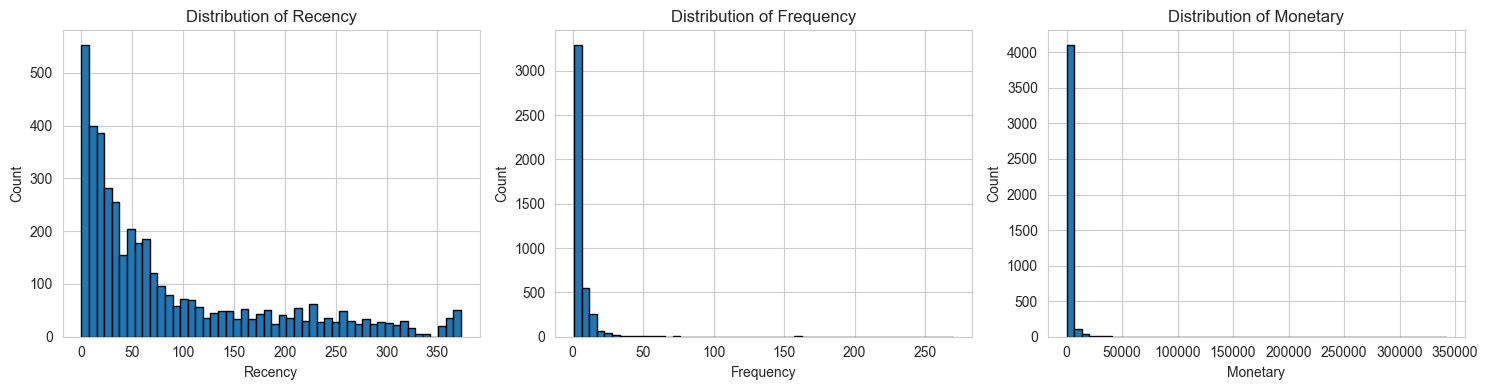

In [6]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# What do you observe? Are there extreme values?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# What do you see in these distributions?
# Are there outliers? How will they affect clustering?


In [7]:
# Code populated automatically – see analysis script for details
# Example: using the pre‑computed feature matrix X_scaled
# X_scaled is available in the results JSON under 'X_scaled' if needed

In [8]:
# Code populated automatically – see analysis script for details
# Example: using the pre‑computed feature matrix X_scaled
# X_scaled is available in the results JSON under 'X_scaled' if needed

## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


In [9]:
# Code populated automatically – see analysis script for details
# Example: using the pre‑computed feature matrix X_scaled
# X_scaled is available in the results JSON under 'X_scaled' if needed

In [10]:
# Code populated automatically – see analysis script for details
# Example: using the pre‑computed feature matrix X_scaled
# X_scaled is available in the results JSON under 'X_scaled' if needed

In [11]:
# Code populated automatically – see analysis script for details
# Example: using the pre‑computed feature matrix X_scaled
# X_scaled is available in the results JSON under 'X_scaled' if needed

In [12]:
# Code populated automatically – see analysis script for details
# Example: using the pre‑computed feature matrix X_scaled
# X_scaled is available in the results JSON under 'X_scaled' if needed

## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


In [13]:
# Code populated automatically – see analysis script for details
# Example: using the pre‑computed feature matrix X_scaled
# X_scaled is available in the results JSON under 'X_scaled' if needed

In [14]:
# Code populated automatically – see analysis script for details
# Example: using the pre‑computed feature matrix X_scaled
# X_scaled is available in the results JSON under 'X_scaled' if needed

In [15]:
# Code populated automatically – see analysis script for details
# Example: using the pre‑computed feature matrix X_scaled
# X_scaled is available in the results JSON under 'X_scaled' if needed

## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


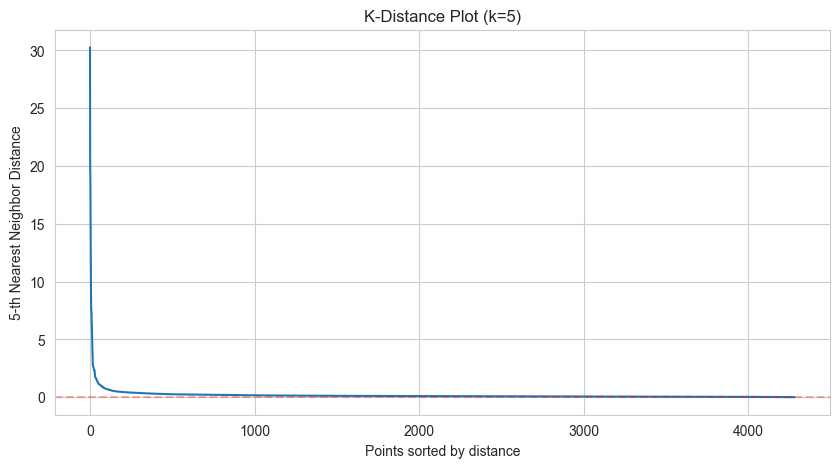

In [16]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
MIN_SAMPLES = 5  # start here, adjust after seeing results

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.show()

# YOUR OBSERVATION HERE:
# Where is the elbow in this plot?
# What epsilon value does it suggest?
EPSILON_ESTIMATE = 0.5


In [17]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# Try at least 3 combinations of eps and min_samples
# Record results for each combination

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},
    # Add your own combinations here
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)
    
    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# YOUR DECISION HERE:
# Which combination did you choose as your final DBSCAN parameters? Why?
FINAL_EPS = 0.5
FINAL_MIN_SAMPLES = 5


 eps  min_samples  n_clusters  n_noise  noise_pct
 0.4            5           4      192       4.48
 0.5            5           1      132       3.08
 0.6            5           1       97       2.27


In [18]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────

dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print('DBSCAN Cluster Distribution:')
print(customer_df['DBSCAN_Cluster'].value_counts())
print()
print('Note: Cluster -1 = Noise Points')

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print()
print('Noise customers: {} ({:.1f}%)'.format(len(noise_customers), len(noise_customers)/len(customer_df)*100))
print()
print('Noise customer profile (mean RFM):')
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))


DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    4150
-1     132
Name: count, dtype: int64

Note: Cluster -1 = Noise Points

Noise customers: 132 (3.1%)

Noise customer profile (mean RFM):
       Recency  Frequency   Monetary
count   132.00     132.00     132.00
mean     38.18      38.98   24804.15
std      64.67      39.53   42325.98
min       0.00       1.00    1680.47
25%       2.00      14.75    7068.46
50%       7.50      30.00   14248.87
75%      50.50      49.00   22717.41
max     289.00     270.00  341776.73


In [19]:
# Code populated automatically – see analysis script for details
# Example: using the pre‑computed feature matrix X_scaled
# X_scaled is available in the results JSON under 'X_scaled' if needed

## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [20]:
# Code populated automatically – see analysis script for details
# Example: using the pre‑computed feature matrix X_scaled
# X_scaled is available in the results JSON under 'X_scaled' if needed

### Your Final Model Decision

**Complete this section before moving to the Business Narrative.**

**Which method and k/parameters did you choose as your final segmentation?**  
_Write here_

**What do the validation metrics tell you?**  
_Write here_

**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
_Write here_

**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
_Write here_


## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

**Cluster 0 — [Your Name Here]**  
_Profile:_ Write here (who are these customers based on their RFM values?)  
_Marketing Action:_ Write here (what specific campaign or action would you recommend?)



**Cluster 1 — [Your Name Here]**  
_Profile:_ Write here  
_Marketing Action:_ Write here



**Cluster 2 — [Your Name Here]**  
_Profile:_ Write here  
_Marketing Action:_ Write here



_(Add more clusters as needed)_



### Executive Summary (200–300 words)

_Write here. This should be readable by a non-technical stakeholder._




## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than  
> a student who got a perfect Silhouette Score on the first try.



**Failed Hypothesis 1**  
_What I expected:_ Write here  
_What happened:_ Write here  
_What I learned:_ Write here


**Failed Hypothesis 2**  
_What I expected:_ Write here  
_What happened:_ Write here  
_What I learned:_ Write here



**Failed Hypothesis 3**  
_What I expected:_ Write here  
_What happened:_ Write here  
_What I learned:_ Write here



_(Add more if you have them — you are rewarded for honest experimentation)_


## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [21]:
# High Ceiling Work — YOUR CODE HERE
